# Statistik in Python

## Kapitel 1

## 1.1 Einführung & Datenhandling in Python

In diesem Abschnitt lernst du:

- wie du die wichtigsten Bibliotheken lädst  
- wie du Daten aus einer `.csv`-Datei einliest und speicherst  
- wie du mit einem `DataFrame` arbeitest (Spalten auswählen, filtern, neue Variablen)

Wir benutzen vor allem:

- `numpy` – Rechnen mit Arrays
- `pandas` – Arbeiten mit Tabellen (DataFrames)
- `matplotlib` & `seaborn` – einfache Grafiken


In [2]:
# Zelle 1: Wichtige Bibliotheken laden

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: schönere Plots
sns.set()

# Optional: pandas-Ausgabe etwas breiter machen
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 80)

## 1.2 Daten einlesen – `pd.read_csv`

Die häufigste Datenquelle im Kurs sind `.csv`-Dateien.

Typische Schritte:

1. Datei-Pfad angeben  
2. `pd.read_csv(...)` benutzen  
3. einen `DataFrame`-Namen wählen (z.B. `df`)  


In [3]:
# Zelle 2: Ein einfaches Beispiel zum Einlesen
# -> Dateinamen anpassen!

df = pd.read_csv("Titanic-Dataset.csv")  # z.B. "titanic.csv", "noten.csv", ...

# ersten Blick auf die Daten
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Zelle 3: Häufige Optionen von read_csv – Überblick

df = pd.read_csv(
    "Titanic-Dataset.csv",
    sep=",",           # Spaltentrenner, z.B. ";" bei deutschen CSVs
    decimal=".",       # Dezimaltrennzeichen, oft "," bei deutschen Dateien
    na_values=["NA", "", "?"],  # fehlende Werte automatisch erkennen
    encoding="utf-8",  # Zeichenkodierung, z.B. "latin-1" bei alten Dateien
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Zelle 4: Überblick über die eingelesenen Daten

print("Form (Zeilen, Spalten):", df.shape)

Form (Zeilen, Spalten): (891, 12)


In [6]:
print("\nSpalten und Datentypen:")
print(df.dtypes)


Spalten und Datentypen:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [7]:
print("\nKurze Info:")
df.info()


Kurze Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Daten speichern – `DataFrame.to_csv`

Wenn du deine bearbeiteten Daten speichern willst, nutzt du meist `to_csv`.


In [8]:
# Zelle 5: DataFrame als CSV speichern

# Speichert df im aktuellen Ordner als "data_clean.csv"
df.to_csv("data_clean.csv", index=False)  # index=False -> keine Zeilennummern mitschreiben


## 1.3 Grundlegende DataFrame-Operationen

Hier ein Mini-Cheat-Sheet für typische Dinge:

- Spalten auswählen
- Zeilen filtern
- neue Spalten berechnen
- Datentypen prüfen und umwandeln


In [9]:
# Zelle 6: Spalten auswählen

# eine Spalte (als Series)
alter = df["Age"]            # oder df.Age, wenn der Name kein Leerzeichen enthält

# mehrere Spalten (als DataFrame)
auswahl = df[["Age", "Sex", "Survived"]]


In [10]:
alter.head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [11]:
auswahl.head()

,Age,Sex,Survived
0,22.0,male,0
1,38.0,female,1
2,26.0,female,1
3,35.0,female,1
4,35.0,male,0


In [12]:
# Zelle 7: Zeilen filtern (Titanic-Daten)

# Beispiel: Alle Passagiere über 30
df_age30 = df[df["Age"] > 30]

# Beispiel: Alle Frauen
df_female = df[df["Sex"] == "female"]

# Beispiel: Männer über 30, die 1 oder mehr Geschwister/Partner dabei haben
df_male30_sib = df[(df["Sex"] == "male") & (df["Age"] > 30) & (df["SibSp"] >= 1)]

# Beispiel: Embarked aus S oder C (Southampton / Cherbourg)
df_emb = df[df["Embarked"].isin(["S", "C"])]

df_age30.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


In [13]:
# Zelle 8: Neue Spalten erstellen (Titanic)

# Reisetyp: allein oder nicht
df["Travel_Alone"] = np.where((df["SibSp"] == 0) & (df["Parch"] == 0), "Alone", "Not alone")

# Kinder / Erwachsene (Cut)
df["Age_Group"] = np.where(df["Age"] < 16, "Child", "Adult")

# Überleben als String Kategorie
df["Survived_Label"] = df["Survived"].map({0: "Died", 1: "Survived"})

df[["Age", "SibSp", "Parch", "Travel_Alone", "Age_Group", "Survived_Label"]].head()


,Age,SibSp,Parch,Travel_Alone,Age_Group,Survived_Label
0,22.0,1,0,Not alone,Adult,Died
1,38.0,1,0,Not alone,Adult,Survived
2,26.0,0,0,Alone,Adult,Survived
3,35.0,1,0,Not alone,Adult,Survived
4,35.0,0,0,Alone,Adult,Died


In [14]:
# Zelle 9: Datentypen prüfen und umwandeln (Titanic)

# aktuelle Typen
print("Vorher:")
print(df.dtypes)

Vorher:
PassengerId         int64
Survived            int64
Pclass              int64
Name               object
Sex                object
Age               float64
SibSp               int64
Parch               int64
Ticket             object
Fare              float64
Cabin              object
Embarked           object
Travel_Alone       object
Age_Group          object
Survived_Label     object
dtype: object


In [15]:
# Sex als category
df["Sex"] = df["Sex"].astype("category")

# Embarked als category
df["Embarked"] = df["Embarked"].astype("category")

# Pclass als category (macht oft Sinn)
df["Pclass"] = df["Pclass"].astype("category")


In [16]:
print("\nNachher:")
print(df[["Sex", "Embarked", "Pclass"]].dtypes)


Nachher:
Sex         category
Embarked    category
Pclass      category
dtype: object


In [17]:
# Zelle 10: Fehlende Werte untersuchen

# Anzahl fehlender Werte pro Spalte
df.isna().sum()


PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
Travel_Alone        0
Age_Group           0
Survived_Label      0
dtype: int64

In [18]:
# Zelle 11: Fehlende Werte behandeln (Beispiele)

# Beispiel: fehlende Age mit Median ersetzen (nicht wissenschaftlich, nur technisches Beispiel)
df["Age_filled"] = df["Age"].fillna(df["Age"].median())

# Beispiel: Embarked fehlende Werte mit häufigstem Wert ersetzen
df["Embarked_filled"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


In [19]:
df[["Age", "Age_filled", "Embarked", "Embarked_filled"]].head(10)

,Age,Age_filled,Embarked,Embarked_filled
0,22.0,22.0,S,S
1,38.0,38.0,C,C
2,26.0,26.0,S,S
3,35.0,35.0,S,S
4,35.0,35.0,S,S
5,NaN,28.0,Q,Q
6,54.0,54.0,S,S
7,2.0,2.0,S,S
8,27.0,27.0,S,S
9,14.0,14.0,C,C


In [20]:
# Zelle 12: Sortieren & Auswählen

# teuerste Tickets zuerst
df_sorted_fare = df.sort_values("Fare", ascending=False)

# jüngste Frauen
df_young_females = df[df["Sex"] == "female"].sort_values("Age").head(10)


In [21]:
df_sorted_fare.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Travel_Alone,Age_Group,Survived_Label,Age_filled,Embarked_filled
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,Alone,Adult,Survived,35.0,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,Alone,Adult,Survived,35.0,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,Not alone,Adult,Survived,36.0,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,Not alone,Adult,Survived,23.0,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,Not alone,Adult,Died,19.0,S


In [22]:
# Zelle 13: Gruppieren – Beispiele (Titanic) ohne FutureWarning

# durchschnittliches Alter nach Klasse
age_by_class = df.groupby("Pclass", observed=False)["Age"].mean()

# Überlebensrate nach Geschlecht
survival_by_sex = df.groupby("Sex", observed=False)["Survived"].mean()

# Überlebensrate nach Pclass und Sex
survival_pclass_sex = df.groupby(["Pclass", "Sex"], observed=False)["Survived"].mean()


In [23]:
age_by_class

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [24]:
survival_by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [25]:
survival_pclass_sex

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [26]:
# Zelle 14: Crosstab / Häufigkeitstabellen

# Verhältnis Geschlecht vs. Überleben
ct = pd.crosstab(df["Sex"], df["Survived_Label"])

# Normalisiert (relative Werte)
ct_norm = pd.crosstab(df["Sex"], df["Survived_Label"], normalize="index")

In [27]:
ct

Survived_Label,Died,Survived
Sex,,
female,81,233
male,468,109


In [28]:
ct_norm

Survived_Label,Died,Survived
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


# Abschnitt 2 – Deskriptive Statistik & Visualisierung

In diesem Abschnitt lernst du:

- Kennzahlen für **Lage**, **Streuung**, **Quantile** und einfache **Formmaße**
- wie du deskriptive Statistiken nach Gruppen berechnest (z.B. nach `Sex`, `Pclass`)
- wie du typische Grafiken mit `seaborn` erstellst (Balken, Histogramm, Boxplot, Scatterplot)


In [29]:
# Zelle 15: Kurzer Blick auf ein paar wichtige Variablen

df[["Survived", "Survived_Label", "Pclass", "Sex", "Age", "Fare", "Travel_Alone", "Embarked"]].head()


,Survived,Survived_Label,Pclass,Sex,Age,Fare,Travel_Alone,Embarked
0,0,Died,3,male,22.0,7.2500,Not alone,S
1,1,Survived,1,female,38.0,71.2833,Not alone,C
2,1,Survived,3,female,26.0,7.9250,Alone,S
3,1,Survived,1,female,35.0,53.1000,Not alone,S
4,0,Died,3,male,35.0,8.0500,Alone,S


## 2.1 Lagemaße

Typische Lagemaße (für quantitative Variablen):

- **Mittelwert**: `Series.mean()`
- **Median**:   `Series.median()`
- **Modus**:    `Series.mode()`

Für Anteile (z.B. Überlebensrate) kann man den Mittelwert einer 0/1-Variable benutzen.


In [30]:
# Zelle 16: Lagemaße für Age und Fare

age_mean   = df["Age"].mean()
age_median = df["Age"].median()
age_mode   = df["Age"].mode()        # kann mehrere Werte haben

fare_mean   = df["Fare"].mean()
fare_median = df["Fare"].median()

print("Age – mean:", age_mean)
print("Age – median:", age_median)
print("Age – mode(s):")
print(age_mode)

print("\nFare – mean:", fare_mean)
print("Fare – median:", fare_median)


Age – mean: 29.69911764705882
Age – median: 28.0
Age – mode(s):
0    24.0
Name: Age, dtype: float64

Fare – mean: 32.204207968574636
Fare – median: 14.4542


In [31]:
# Zelle 17: Überlebensrate (Anteil Survived = 1)

survival_rate = df["Survived"].mean()
print("Überlebensrate (Anteil Survived=1):", survival_rate)


Überlebensrate (Anteil Survived=1): 0.3838383838383838


## 2.2 Quantile und `describe`

Wichtige Befehle:

- `Series.quantile(q)` – q kann z.B. 0.25, 0.5, 0.75 sein
- `Series.describe()` – schnelle Übersicht (count, mean, std, min, Quartile, max)


In [32]:
# Zelle 18: Quantile für Age

age_quantiles = df["Age"].quantile([0.25, 0.5, 0.75])
print(age_quantiles)


0.25    20.125
0.50    28.000
0.75    38.000
Name: Age, dtype: float64


In [33]:
# Zelle 19: describe für mehrere Variablen

df[["Age", "Fare"]].describe()


,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


## 2.3 Streuungsmaße

Typische Streuungsmaße:

- **Varianz**: `Series.var()`
- **Standardabweichung**: `Series.std()`
- **Spannweite (Range)**: `max - min`
- **Interquartilsabstand (IQR)**: Q3 - Q1


In [34]:
# Zelle 20: Streuung für Age

age_var  = df["Age"].var()
age_std  = df["Age"].std()
age_min  = df["Age"].min()
age_max  = df["Age"].max()
age_iqr  = df["Age"].quantile(0.75) - df["Age"].quantile(0.25)

print("Age – Varianz:", age_var)
print("Age – Standardabweichung:", age_std)
print("Age – Minimum:", age_min)
print("Age – Maximum:", age_max)
print("Age – IQR:", age_iqr)


Age – Varianz: 211.0191247463081
Age – Standardabweichung: 14.526497332334044
Age – Minimum: 0.42
Age – Maximum: 80.0
Age – IQR: 17.875


## 2.4 Einfache Formmaße (Schiefe, Wölbung)

- **Schiefe** (skewness): `Series.skew()`
- **Exzess (kurtosis)**: `Series.kurtosis()`
  
Das ist eher „nice to know“, hilft aber bei der Form der Verteilung.


In [35]:
# Zelle 21: Schiefe und Wölbung für Age

age_skew = df["Age"].skew()
age_kurt = df["Age"].kurtosis()

print("Age – Schiefe (skew):", age_skew)
print("Age – Wölbung (kurtosis):", age_kurt)


Age – Schiefe (skew): 0.38910778230082704
Age – Wölbung (kurtosis): 0.17827415364210353


## 2.5 Deskriptive Statistik nach Gruppen

Sehr häufig wollen wir Kennzahlen **für verschiedene Gruppen** vergleichen, z.B.:

- mittleres Alter nach Klasse (`Pclass`)
- Überlebensrate nach Geschlecht (`Sex`)
- Fare nach Embarked-Hafen (`Embarked`)

Dafür benutzen wir `groupby(...).agg(...)`.


In [36]:
# Zelle 22: Mittleres Alter nach Pclass

age_by_class = df.groupby("Pclass", observed=False)["Age"].mean()
age_by_class


Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [37]:
# Zelle 23: Überlebensrate nach Geschlecht

survival_by_sex = df.groupby("Sex", observed=False)["Survived"].mean()
survival_by_sex


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [38]:
# Zelle 24: Überlebensrate nach Pclass und Sex

survival_pclass_sex = (
    df.groupby(["Pclass", "Sex"], observed=False)["Survived"]
      .agg(["mean", "count"])
)
survival_pclass_sex


mean  count
Pclass Sex                    
1      female  0.968085     94
       male    0.368852    122
2      female  0.921053     76
       male    0.157407    108
3      female  0.500000    144
       male    0.135447    347

## 2.6 Einfache Grafiken mit `seaborn`

Wir nutzen:

- `sns.countplot` für kategoriale Variablen
- `sns.histplot` für Histogramme
- `sns.boxplot` für Verteilungen nach Gruppen
- `sns.scatterplot` für Zusammenhänge (bivariat)

> Hinweis: In Jupyter brauchst du i.d.R. kein `plt.show()`, aber es schadet nicht.


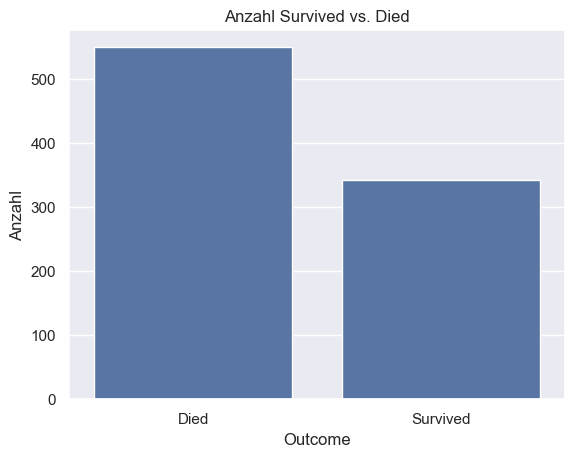

In [39]:
# Zelle 25: Balkendiagramm – Anzahl Überlebende vs. Nicht-Überlebende

plt.figure()
sns.countplot(data=df, x="Survived_Label")
plt.title("Anzahl Survived vs. Died")
plt.xlabel("Outcome")
plt.ylabel("Anzahl")
plt.show()


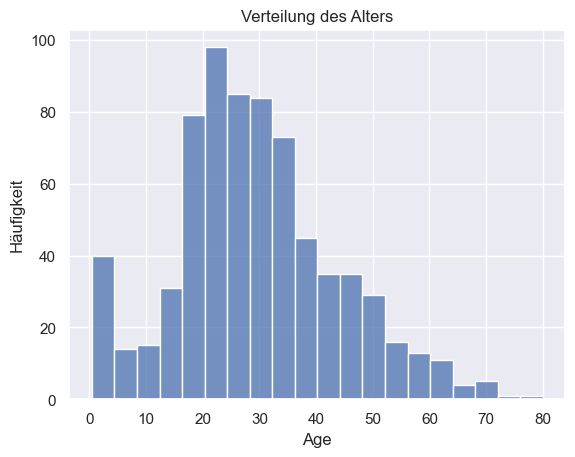

In [42]:
# Zelle 26: Histogramm – Altersverteilung

plt.figure()
sns.histplot(data=df, x="Age", bins=20)
plt.title("Verteilung des Alters")
plt.xlabel("Age")
plt.ylabel("Häufigkeit")
plt.show()


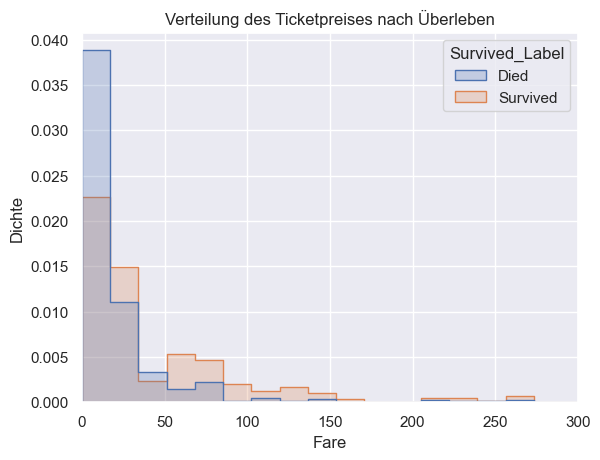

In [43]:
# Zelle 27: Histogramm – Fare nach Überleben (Hue)

plt.figure()
sns.histplot(data=df, x="Fare", bins=30, hue="Survived_Label", element="step", stat="density", common_norm=False)
plt.xlim(0, 300)  # Extremwerte etwas abschneiden für bessere Sicht
plt.title("Verteilung des Ticketpreises nach Überleben")
plt.xlabel("Fare")
plt.ylabel("Dichte")
plt.show()


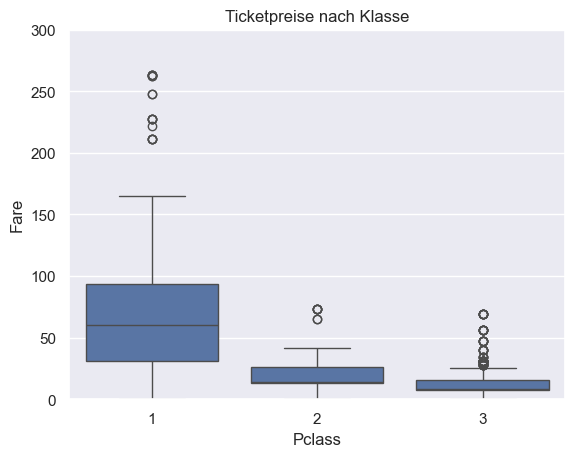

In [44]:
# Zelle 28: Boxplot – Fare nach Pclass

plt.figure()
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.ylim(0, 300)
plt.title("Ticketpreise nach Klasse")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()


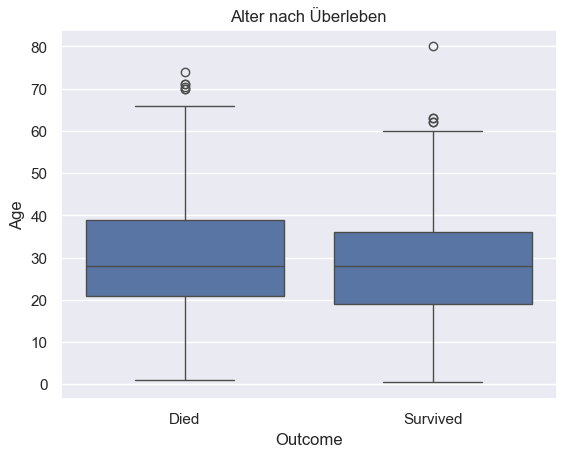

In [45]:
# Zelle 29: Boxplot – Age nach Survived_Label

plt.figure()
sns.boxplot(data=df, x="Survived_Label", y="Age")
plt.title("Alter nach Überleben")
plt.xlabel("Outcome")
plt.ylabel("Age")
plt.show()


## 2.7 Bivariate Daten: Kovarianz & Korrelation

Wichtige Befehle:

- `df.cov()` – Kovarianzmatrix
- `df.corr()` – Korrelationsmatrix (standardmäßig Pearson)


In [46]:
# Zelle 30: Kovarianz und Korrelation für Age und Fare

num_vars = df[["Age", "Fare"]]

cov_matrix  = num_vars.cov()
corr_matrix = num_vars.corr()

print("Kovarianzmatrix:")
print(cov_matrix)

print("\nKorrelationsmatrix:")
print(corr_matrix)


Kovarianzmatrix:
             Age         Fare
Age   211.019125    73.849030
Fare   73.849030  2469.436846

Korrelationsmatrix:
           Age      Fare
Age   1.000000  0.096067
Fare  0.096067  1.000000


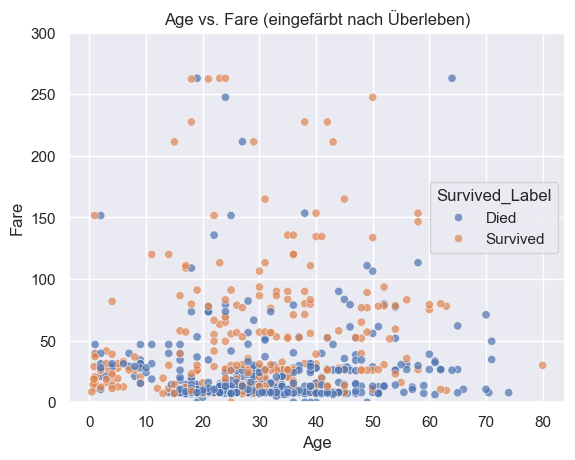

In [47]:
# Zelle 31: Scatterplot – Age vs. Fare

plt.figure()
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived_Label", alpha=0.7)
plt.ylim(0, 300)
plt.title("Age vs. Fare (eingefärbt nach Überleben)")
plt.show()


### Zusammenfassung Abschnitt 2

- **Lagemaße:** `mean`, `median`, `mode`
- **Quantile & Übersicht:** `quantile`, `describe`
- **Streuung:** `var`, `std`, Range, IQR
- **Form:** `skew`, `kurtosis`
- **Gruppenvergleiche:** `groupby(...).agg(...)`
- **Plots (seaborn):** `countplot`, `histplot`, `boxplot`, `scatterplot`
- **Zusammenhang quantitativer Variablen:** `cov()`, `corr()`, Scatterplots

Als Nächstes könnten wir **Abschnitt 3 – Wahrscheinlichkeit & Verteilungen (Simulation mit `numpy` und `scipy.stats`)** als Notebook-Zellen aufbauen.


# Abschnitt 3 – Wahrscheinlichkeit & Verteilungen

In diesem Abschnitt lernst du:

- wie man Zufallszahlen mit `numpy` simuliert (z.B. Münzwurf, Würfel, Stichproben)
- wie man mit `scipy.stats` Verteilungen benutzt:
  - Zufallszahlen ziehen (`.rvs`)
  - Wahrscheinlichkeiten berechnen (`.pmf` / `.pdf`)
  - Verteilungsfunktionen (`.cdf`, `.sf`)
  - Quantile (`.ppf`)
- Beispiele für wichtige Verteilungen:
  - Bernoulli & Binomial
  - Normalverteilung
  - ggf. Poisson


In [48]:
# Zelle 32: Bibliotheken für Wahrscheinlichkeit & Verteilungen

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

## 3.1 Zufallszahlen & einfache Simulationen mit `numpy`

Wir benutzen das Modul `np.random` für:

- **Münzwurf** (0/1)
- **Würfelwurf** (1–6)
- **allgemeine diskrete Auswahl** (`np.random.choice`)

Wichtig:
- `np.random.seed(...)` setzt einen Startwert → Ergebnisse werden reproduzierbar.


In [50]:
# Zelle 33: Münzwürfe simulieren (0 = Kopf, 1 = Zahl)

np.random.seed(42)            # Startwert setzen

# 10 Münzwürfe
coins_10 = np.random.binomial(n=1, p=0.5, size=10)
print("10 Münzwürfe:", coins_10)

# 1000 Münzwürfe
coins_1000 = np.random.binomial(n=1, p=0.5, size=1000)

# Anteil der 1er (Zahl)
prop_ones = coins_1000.mean()
print("Anteil Zahl bei 1000 Würfen:", prop_ones)


10 Münzwürfe: [0 1 1 1 0 0 0 1 1 1]
Anteil Zahl bei 1000 Würfen: 0.498


In [51]:
# Zelle 34: Würfelwürfe simulieren (1–6) mit np.random.randint

np.random.seed(42)

# 10 Würfe
dice_10 = np.random.randint(low=1, high=7, size=10)  # high=7 -> 1..6
print("10 Würfelwürfe:", dice_10)

# 1000 Würfe
dice_1000 = np.random.randint(1, 7, size=1000)

# relative Häufigkeiten
unique, counts = np.unique(dice_1000, return_counts=True)
rel_freq = counts / len(dice_1000)

print("\nAugenzahl   Relative Häufigkeit")
for u, f in zip(unique, rel_freq):
    print(f"{u:>3}         {f:0.3f}")


10 Würfelwürfe: [4 5 3 5 5 2 3 3 3 5]

Augenzahl   Relative Häufigkeit
  1         0.181
  2         0.163
  3         0.151
  4         0.174
  5         0.169
  6         0.162


In [52]:
# Zelle 35: Allgemeine Auswahl mit np.random.choice

np.random.seed(42)

farben = np.array(["rot", "grün", "blau"])

# 12 Zufallsfarben, alle gleichwahrscheinlich
colors_12 = np.random.choice(farben, size=12)
print("12 Zufallsfarben:", colors_12)

# mit Wahrscheinlichkeiten (z.B. rot: 0.5, grün: 0.3, blau: 0.2)
colors_1000 = np.random.choice(farben, size=1000, p=[0.5, 0.3, 0.2])

unique, counts = np.unique(colors_1000, return_counts=True)
rel_freq = counts / len(colors_1000)

print("\nRelative Häufigkeiten bei gewichteter Auswahl:")
for u, f in zip(unique, rel_freq):
    print(f"{u:>4}: {f:0.3f}")


12 Zufallsfarben: ['blau' 'rot' 'blau' 'blau' 'rot' 'rot' 'blau' 'grün' 'blau' 'blau' 'blau'
 'blau']

Relative Häufigkeiten bei gewichteter Auswahl:
blau: 0.200
grün: 0.300
 rot: 0.500


## 3.2 Verteilungen mit `scipy.stats`

`scipy.stats` bietet **Verteilungsobjekte**, z.B.:

- `stats.bernoulli(p=...)`
- `stats.binom(n=..., p=...)`
- `stats.norm(loc=..., scale=...)` (Normalverteilung)
- `stats.poisson(mu=...)`

Diese liefern Methoden:

- `.rvs(size=...)` – Zufallszahlen
- `.pmf(k)` – Wahrscheinlichkeit P(X = k) (diskrete Verteilung)
- `.pdf(x)` – Dichte f(x) (stetige Verteilung)
- `.cdf(x)` – Verteilungsfunktion P(X ≤ x)
- `.sf(x)` – survival function P(X > x)
- `.ppf(q)` – q-Quantil


In [54]:
# Zelle 36: Bernoulli-Verteilung – einzelner Münzwurf

# X ~ Bernoulli(p=0.5)
bern = stats.bernoulli(p=0.5)

# Wahrscheinlichkeiten
p0 = bern.pmf(0)  # P(X = 0)
p1 = bern.pmf(1)  # P(X = 1)

print("P(X=0):", p0)
print("P(X=1):", p1)

# Erwartungswert & Varianz
print("Erwartungswert:", bern.mean())
print("Varianz:", bern.var())


P(X=0): 0.5000000000000001
P(X=1): 0.5
Erwartungswert: 0.5
Varianz: 0.25


In [55]:
# Zelle 37: Binomialverteilung – Anzahl Treffer in n Versuchen

# Beispiel: X ~ Binomial(n=10, p=0.3)
binom_dist = stats.binom(n=10, p=0.3)

# Wahrscheinlichkeit genau 4 Treffer
p4 = binom_dist.pmf(4)
print("P(X=4) für X~Bin(10,0.3):", p4)

# kumulierte Wahrscheinlichkeit P(X <= 4)
p_le4 = binom_dist.cdf(4)
print("P(X<=4):", p_le4)

# ergänzend: P(X > 4)
p_gt4 = binom_dist.sf(4)   # sf = 1 - cdf
print("P(X>4):", p_gt4)


P(X=4) für X~Bin(10,0.3): 0.2001209489999999
P(X<=4): 0.8497316674000001
P(X>4): 0.15026833259999992


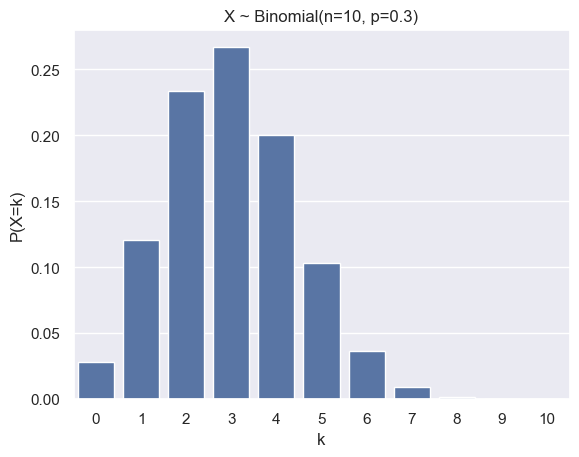

In [56]:
# Zelle 38: Binomialverteilung – Verteilung zeichnen

k_values = np.arange(0, 11)  # mögliche Werte 0..10
pmf_values = binom_dist.pmf(k_values)

plt.figure()
sns.barplot(x=k_values, y=pmf_values)
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.title("X ~ Binomial(n=10, p=0.3)")
plt.show()


## 3.3 Normalverteilung mit `scipy.stats.norm`

Normalverteilung: `X ~ N(μ, σ²)`  
In `scipy.stats`:

- `stats.norm(loc=μ, scale=σ)`

Wichtige Fragen:

- P(X ≤ x) → `.cdf(x)`
- Dichte f(x) → `.pdf(x)`
- Quantile: x mit P(X ≤ x) = q → `.ppf(q)`


In [57]:
# Zelle 39: Standardnormalverteilung N(0,1)

std_norm = stats.norm(loc=0, scale=1)

p_le_1 = std_norm.cdf(1)     # P(Z <= 1)
p_ge_1_96 = std_norm.sf(1.96)  # P(Z > 1.96)

print("P(Z <= 1) für Z~N(0,1):", p_le_1)
print("P(Z > 1.96):", p_ge_1_96)

# 97.5%-Quantil (soll ~1.96 sein)
q_975 = std_norm.ppf(0.975)
print("97.5%-Quantil:", q_975)


P(Z <= 1) für Z~N(0,1): 0.8413447460685429
P(Z > 1.96): 0.024997895148220435
97.5%-Quantil: 1.959963984540054


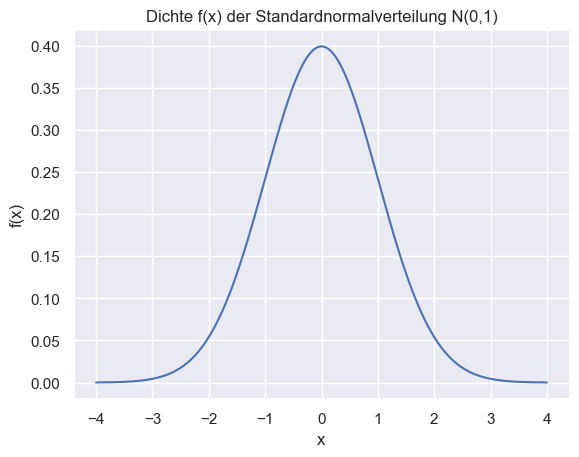

In [58]:
# Zelle 40: Dichte der Standardnormalverteilung zeichnen

x_vals = np.linspace(-4, 4, 400)
pdf_vals = std_norm.pdf(x_vals)

plt.figure()
plt.plot(x_vals, pdf_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Dichte f(x) der Standardnormalverteilung N(0,1)")
plt.show()


In [59]:
# Zelle 41: Allgemeine Normalverteilung N(μ, σ²)

mu = 50
sigma = 10
norm_dist = stats.norm(loc=mu, scale=sigma)

# Beispiel: P(X <= 60)
p_le_60 = norm_dist.cdf(60)
print(f"P(X <= 60) für X~N({mu},{sigma**2}):", p_le_60)

# Beispiel: 2.5%- und 97.5%-Quantil
q_025 = norm_dist.ppf(0.025)
q_975 = norm_dist.ppf(0.975)
print("2.5%-Quantil:", q_025)
print("97.5%-Quantil:", q_975)


P(X <= 60) für X~N(50,100): 0.8413447460685429
2.5%-Quantil: 30.400360154599454
97.5%-Quantil: 69.59963984540053


## 3.4 Poisson-Verteilung (optional)

Typisch für **Ereignisse in einem Zeitintervall**:  
X ~ Poisson(λ), z.B. Anzahl Anrufe pro Stunde, Fehler pro Seite.

In `scipy.stats`: `stats.poisson(mu=λ)`


P(X=0) für X~Pois(2.5): 0.0820849986238988
P(X=1): 0.205212496559747
P(X<=3): 0.7575761331330662


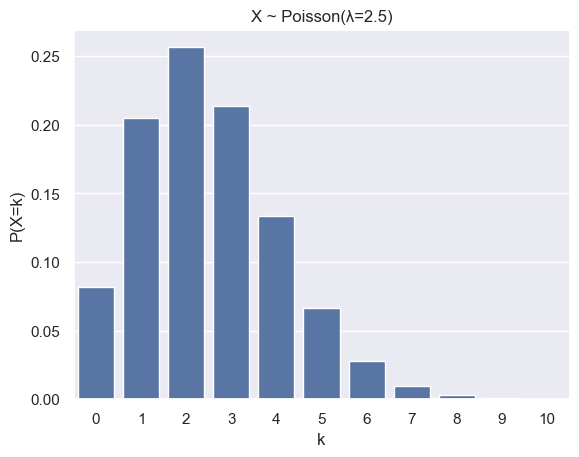

In [60]:
# Zelle 42: Poissonverteilung – Beispiel

# X ~ Poisson(λ = 2.5)
pois_dist = stats.poisson(mu=2.5)

# P(X = 0), P(X = 1), P(X <= 3)
p0 = pois_dist.pmf(0)
p1 = pois_dist.pmf(1)
p_le3 = pois_dist.cdf(3)

print("P(X=0) für X~Pois(2.5):", p0)
print("P(X=1):", p1)
print("P(X<=3):", p_le3)

# Verteilung zeichnen
k_vals = np.arange(0, 11)
pmf_vals = pois_dist.pmf(k_vals)

plt.figure()
sns.barplot(x=k_vals, y=pmf_vals)
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.title("X ~ Poisson(λ=2.5)")
plt.show()


### Mini-Zusammenfassung Abschnitt 3

- **Simulation mit `numpy`:**  
  - Münzwurf: `np.random.binomial(n=1, p=0.5, size=...)`  
  - Würfel: `np.random.randint(1, 7, size=...)`  
  - Auswahl: `np.random.choice(...)`

- **`scipy.stats` Verteilungen:**
  - Bernoulli: `stats.bernoulli(p)`  
  - Binomial: `stats.binom(n, p)`  
  - Normal: `stats.norm(loc, scale)`  
  - Poisson: `stats.poisson(mu)`

- Wichtige Methoden:
  - `.rvs(size)` – Zufallszahlen
  - `.pmf(k)` / `.pdf(x)` – Punktwahrscheinlichkeit / Dichte
  - `.cdf(x)` – P(X ≤ x)
  - `.sf(x)` – P(X > x)
  - `.ppf(q)` – Quantile


# Abschnitt 4 – Stichproben, Stichprobenverteilungen & Zentraler Grenzwertsatz (CLT)

In diesem Abschnitt lernst du:

- wie man **Zufallsstichproben** aus Daten zieht (`df.sample`)
- wie man **mehrfach Stichproben** zieht und daraus eine Stichprobenverteilung baut
- wie man die **Verteilung des Stichprobenmittels** simuliert
- wie sich diese Verteilung mit größerem n an die **Normalverteilung annähert**


In [61]:
# Zelle 43: Wir arbeiten hier wieder mit dem Titanic-Datensatz df
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Travel_Alone,Age_Group,Survived_Label,Age_filled,Embarked_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Not alone,Adult,Died,22.0,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Not alone,Adult,Survived,38.0,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Alone,Adult,Survived,26.0,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Not alone,Adult,Survived,35.0,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Alone,Adult,Died,35.0,S


## 4.1 Zufallsstichproben aus vorhandenen Daten

Wir benutzen `df.sample`:

- `n=` → Anzahl Zeilen
- `frac=` → Anteil (z.B. `frac=0.3`)
- `replace=True` → Ziehen **mit** Zurücklegen
- `random_state=` → reproduzierbare Zufallszahlen


In [62]:
# Zelle 44: 5 zufällige Passagiere aus der Titanic-Liste

sample_5 = df.sample(n=5, random_state=42)
sample_5

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Travel_Alone,Age_Group,Survived_Label,Age_filled,Embarked_filled
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C,Not alone,Adult,Survived,28.0,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S,Alone,Adult,Died,31.0,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S,Alone,Adult,Died,20.0,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S,Not alone,Child,Survived,6.0,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C,Not alone,Child,Survived,14.0,C


In [63]:
# Zelle 45: 30% zufällige Stichprobe

sample_frac = df.sample(frac=0.3, random_state=42)
sample_frac.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Travel_Alone,Age_Group,Survived_Label,Age_filled,Embarked_filled
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C,Not alone,Adult,Survived,28.0,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S,Alone,Adult,Died,31.0,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S,Alone,Adult,Died,20.0,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S,Not alone,Child,Survived,6.0,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C,Not alone,Child,Survived,14.0,C


In [64]:
# Zelle 46: Bootstrapping – Ziehen mit Zurücklegen

bootstrap_sample = df.sample(n=len(df), replace=True, random_state=42)
bootstrap_sample.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Travel_Alone,Age_Group,Survived_Label,Age_filled,Embarked_filled
102,103,0,1,"White, Mr. Richard Frasar",male,21.0,0,1,35281,77.2875,D26,S,Not alone,Adult,Died,21.0,S
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S,Not alone,Child,Survived,14.0,S
860,861,0,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,NaN,S,Not alone,Adult,Died,41.0,S
270,271,0,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S,Alone,Adult,Died,28.0,S
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,NaN,S,Alone,Adult,Survived,21.0,S


## 4.2 Simulation einer Stichprobenverteilung

Wir simulieren viele Stichproben gleicher Größe (z.B. n=30) und berechnen jeweils den **Stichprobenmittelwert** des Alters.

Ziel:
- Die Verteilung dieser Mittelwerte ist die **Stichprobenverteilung des Mittelwerts**.
- Für große n wird sie (fast immer) **normal** – CLT.


In [65]:
# Zelle 47: Eine Funktion, die n Personen zufällig zieht und deren Durchschnittsalter berechnet

def sample_mean_age(n=30):
    sample = df["Age"].dropna().sample(n=n, replace=True)  # replace=True = Bootstrapping
    return sample.mean()

# Test
sample_mean_age(30)


32.233333333333334

In [66]:
# Zelle 48: Viele Stichproben simulieren und Mittelwerte speichern

np.random.seed(42)

n = 30          # Stichprobengröße
B = 5000        # Anzahl der Wiederholungen

means = np.array([sample_mean_age(n) for _ in range(B)])

# Überblick
print("Anzahl simulierte Stichproben:", len(means))
print("Mittelwert der Mittelwerte:", means.mean())
print("Standardabweichung der Mittelwerte:", means.std())


Anzahl simulierte Stichproben: 5000
Mittelwert der Mittelwerte: 29.738917999999998
Standardabweichung der Mittelwerte: 2.648184202318512


## 4.3 Stichprobenverteilung des Mittelwerts visualisieren

Die Verteilung der Mittelwerte sollten (bei n ≥ 30) **glockenförmig** aussehen.  


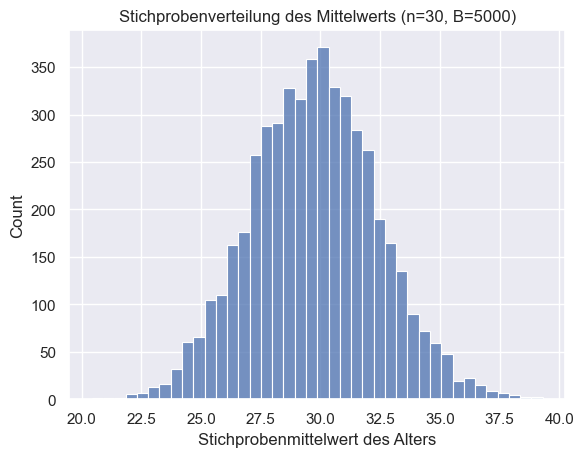

In [68]:
# Zelle 49: Histogramm der Stichprobenmittelwerte

plt.figure()
sns.histplot(means, bins=40)
plt.xlabel("Stichprobenmittelwert des Alters")
plt.title(f"Stichprobenverteilung des Mittelwerts (n={n}, B={B})")
plt.show()


## 4.4 Vergleich mit einer Normalverteilung

Theoretisch gilt für den Mittelwert:

$$
\bar X \approx N\left(\mu, \frac{\sigma^2}{n}\right)
$$

mit  
- μ = Populationsmittelwert  
- σ = Populationsstandardabweichung  

Wir schätzen diese Werte aus den Daten.


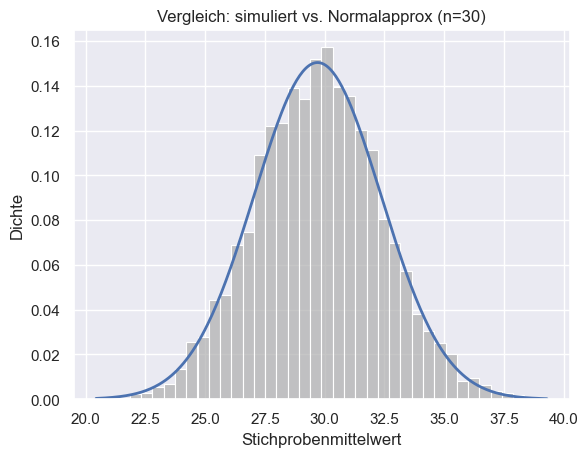

In [69]:
# Zelle 50: theoretische Normalverteilung zum Vergleich

mu_hat = df["Age"].mean()
sigma_hat = df["Age"].std()

mean_theo = mu_hat
sd_theo = sigma_hat / np.sqrt(n)

# Vergleichsdichte berechnen
x_vals = np.linspace(means.min(), means.max(), 300)
theo_pdf = stats.norm(loc=mean_theo, scale=sd_theo).pdf(x_vals)

plt.figure()
sns.histplot(means, bins=40, stat="density", color="0.7")
plt.plot(x_vals, theo_pdf, linewidth=2)
plt.xlabel("Stichprobenmittelwert")
plt.ylabel("Dichte")
plt.title(f"Vergleich: simuliert vs. Normalapprox (n={n})")
plt.show()


## 4.5 Einfluss der Stichprobengröße n

Der Zentrale Grenzwertsatz sagt:

- Für **größeres n** wird die Stichprobenverteilung
  - *schmaler* (kleinere Streuung)
  - *normaler* (symmetrisch, glockenförmig)

Wir simulieren das für n = 5, 30, 100.


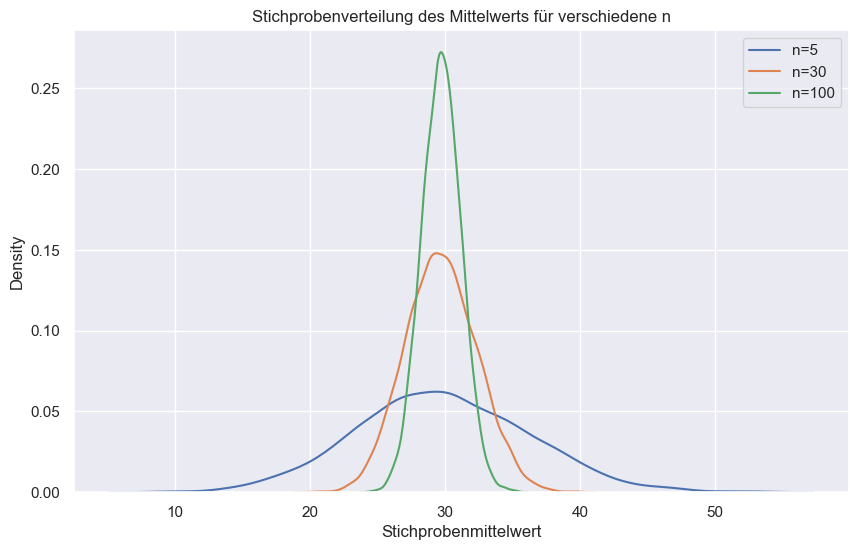

In [70]:
# Zelle 51: CLT-Vergleich für verschiedene n

def simulate_means(n, B=5000):
    return np.array([
        df["Age"].dropna().sample(n=n, replace=True).mean()
        for _ in range(B)
    ])

np.random.seed(42)

means_5   = simulate_means(5)
means_30  = simulate_means(30)
means_100 = simulate_means(100)

# Plotvergleich
plt.figure(figsize=(10, 6))

sns.kdeplot(means_5,  label="n=5")
sns.kdeplot(means_30, label="n=30")
sns.kdeplot(means_100,label="n=100")

plt.title("Stichprobenverteilung des Mittelwerts für verschiedene n")
plt.xlabel("Stichprobenmittelwert")
plt.legend()
plt.show()


### 4.6 Bootstrapping – Alternative zur Theorie

Vielleicht habt ihr:
- keine genaue Verteilung der Daten
- kleine Stichproben
- komplizierte Funktionen (z.B. Median, Quantile)

Dann hilft das **Bootstrap-Verfahren**.

Beispiel: 95%-Konfidenzintervall für das Alter


In [71]:
# Zelle 52: Bootstrap-KI für Age

np.random.seed(42)

B = 5000
boot_means = np.array([
    df["Age"].dropna().sample(frac=1, replace=True).mean()
    for _ in range(B)
])

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print("Bootstrap-KI (95%) für das mittlere Alter:")
print(ci_lower, ci_upper)


Bootstrap-KI (95%) für das mittlere Alter:
28.640498949579833 30.780998599439773


### Mini-Zusammenfassung Abschnitt 4

- **Zufallsstichprobe:** `df.sample(...)`
- **Stichprobenverteilung:** viele Stichproben → Verteilung eines Kennwertes entsteht
- **CLT:** Für große n wird der Mittelwert fast immer normalverteilt
- **Standardfehler:** $\text{SE} = \sigma / \sqrt{n}$
- **Bootstrapping:** Ziehen mit Zurücklegen → Datenbasiertes Konfidenzintervall

Als nächstes können wir Abschnitt **5 – Parameterschätzung (Punkt- & Intervallschätzer)** bauen – das ist direkt die logische Fortsetzung hiervon.


# Abschnitt 5 – Parameterschätzung (Punkt- & Intervallschätzer)

In diesem Abschnitt lernst du:

- Was ein **Punktschätzer** ist (z.B. Mittelwert, Varianz, Anteil)
- Was ein **Standardfehler** ist und wieso er wichtig ist
- Wie man **Intervallschätzer** (Konfidenzintervalle) mit Python berechnet
- Wann man Normalverteilung vs. t-Verteilung benutzt
- Wie man Konfidenzintervalle für:
  - einen Mittelwert,
  - einen Anteil
  - die Varianz
  berechnet.


Ein **Punktschätzer** ist einfach ein einzelner Zahlenwert, der einen unbekannten Parameter schätzen soll.

Beispiele:

- Mittelwert μ → Schätzer: \(\bar{x}\)
- Varianz σ² → Schätzer: \(s^2\)
- Anteil p → Schätzer: \(\hat{p}\)

In Python:
- Mittelwert: `Series.mean()`
- Varianz:    `Series.var(ddof=1)`  (`ddof=1` = „n−1“, Standard)
- Anteil:     Mittelwert einer 0/1-Variable


In [72]:
# Zelle 53: Punktschätzer für Alter und Überleben

age_mean  = df["Age"].mean()
age_var   = df["Age"].var(ddof=1)
survival_rate = df["Survived"].mean()   # Anteil 1er

print("Geschätzter Mittelwert Age:", age_mean)
print("Geschätzte Varianz Age:", age_var)
print("Überlebensrate (Anteil):", survival_rate)


Geschätzter Mittelwert Age: 29.69911764705882
Geschätzte Varianz Age: 211.0191247463081
Überlebensrate (Anteil): 0.3838383838383838


Der **Standardfehler** ist die Streuung eines Schätzers.

Für den Mittelwert:

$$
SE(\bar X) = \frac{s}{\sqrt{n}}
$$

Für den Anteil:

$$
SE(\hat p) = \sqrt{\frac{\hat p (1-\hat p)}{n}}
$$

In Python rechnen wir das direkt aus.


In [73]:
# Zelle 54: Standardfehler für Mittelwert von Age

n_age = df["Age"].dropna().shape[0]
s_age = df["Age"].std()

se_age = s_age / np.sqrt(n_age)
print("SE(Age):", se_age)


SE(Age): 0.5436404994496713


In [74]:
# Zelle 55: Standardfehler für Überlebensanteil

n_surv = df["Survived"].shape[0]
p_hat  = df["Survived"].mean()

se_p = np.sqrt(p_hat * (1 - p_hat) / n_surv)
print("SE(p):", se_p)


SE(p): 0.01629231015825001


## 5.3 Konfidenzintervalle für den Mittelwert

Wir wollen den unbekannten Erwartungswert \( \mu \) einer Population schätzen.

Der **Punktschätzer** ist der Stichprobenmittelwert:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^n X_i
$$

Ein **Konfidenzintervall (KI)** sagt uns, wie stark dieser Schätzer schwanken kann.

### Zwei Fälle:

**Fall A: Große Stichprobe / σ bekannt oder n groß**  
→ Wir verwenden die **Normalverteilung**  
(Kritischer Wert: \( z_{0.975} = 1.96 \))

**Fall B: σ unbekannt & n klein (< 30)**  
→ Wir verwenden die **t-Verteilung**  
(Kritischer Wert: \( t_{0.975, n-1} \))

Für den Titanic-Datensatz gilt:  
Wir haben viele Beobachtungen → Normal- und t-KI sind fast identisch.

Der **Standardfehler des Mittelwertes** ist:

$$
SE(\bar{x}) = \frac{s}{\sqrt{n}}
$$

Darauf bauen beide Konfidenzintervalle auf.


In [75]:
# Werte für Age berechnen
age = df["Age"].dropna()
n = age.shape[0]
xbar = age.mean()
s = age.std()

SE = s / np.sqrt(n)

xbar, s, SE, n


(29.69911764705882, 14.526497332334044, 0.5436404994496713, 714)

### 5.3.1 KI mit Normalverteilung (große Stichprobe)

Formel:

$$
\bar{x} \pm z_{0.975} \cdot SE
$$

mit $ z_{0.975} = 1.96 $.

Wir berechnen das 95%-KI für das mittlere Alter der Titanic-Passagiere.


In [76]:
# Normal-KI
z = 1.96

ci_lower_norm = xbar - z * SE
ci_upper_norm = xbar + z * SE

ci_lower_norm, ci_upper_norm


(28.633582268137463, 30.764653025980177)

### 5.3.2 KI mit t-Verteilung (σ unbekannt, n klein)

Formel:

$$
\bar{x} \pm t_{0.975,\, n-1} \cdot SE
$$

Die t-Verteilung ist breiter als die Normalverteilung, wenn n klein ist.

Bei Titanic (großes n) ist sie fast identisch zur Normalapproximation.


In [78]:
# t-KI
dfree = n - 1
t_crit = stats.t.ppf(0.975, dfree)

ci_lower_t = xbar - t_crit * SE
ci_upper_t = xbar + t_crit * SE

ci_lower_t, ci_upper_t


(28.631790041821507, 30.766445252296133)

### 5.3.3 Interpretation

Das 95%-Konfidenzintervall bedeutet:

> Wenn wir viele Stichproben solcher Größe ziehen und jedes Mal ein KI berechnen,  
> würden **ca. 95% dieser Intervalle den wahren Mittelwert μ enthalten**.

Wichtig:
- Das KI macht **keine Aussage über eine einzelne Person**, sondern über Unsicherheit des Mittelwert-Schätzers.
- Bei großen n sind Normal- und t-KI praktisch identisch.


## 5.4 Konfidenzintervalle für einen Anteil

Wir betrachten eine **0/1-Variable**, z.B. beim Titanic-Datensatz:

- `Survived = 1` → Person hat überlebt
- `Survived = 0` → Person hat nicht überlebt

Der Schätzer für den Anteil \( p \) ist:

$$
\hat{p} = \frac{\text{Anzahl Erfolge}}{n}
$$

Beispiel: Überlebensrate der Titanic.

### Standardfehler des Anteils

$$
SE(\hat{p}) = \sqrt{\frac{\hat{p}(1 - \hat{p})}{n}}
$$

### 95%-Konfidenzintervall

Für große Stichproben verwenden wir die Normalapproximation:

$$
\hat{p} \pm z_{0.975} \cdot SE(\hat{p})
$$

Bei der Titanic ist die Stichprobe groß genug → Normalapproximation funktioniert gut.


In [79]:
# Anteil p und Standardfehler SE(p)
p_hat = df["Survived"].mean()
n_p   = df["Survived"].shape[0]

SE_p = np.sqrt(p_hat * (1 - p_hat) / n_p)

p_hat, SE_p, n_p


(0.3838383838383838, 0.01629231015825001, 891)

### 95%-Konfidenzintervall für den Anteil

Wir benutzen wieder den kritischen Wert der Standardnormalverteilung:

$$
z_{0.975} = 1.96
$$

Das liefert das 95%-Konfidenzintervall:


In [81]:
# 95%-Konfidenzintervall für den Anteil (Normalapproximation)

z = 1.96

ci_lower_p = p_hat - z * SE_p
ci_upper_p = p_hat + z * SE_p

ci_lower_p, ci_upper_p


(0.35190545592821376, 0.41577131174855386)

### Interpretation

Das 95%-Konfidenzintervall für den Überlebensanteil sagt:

> Wenn wir viele Stichproben der Größe n ziehen und jedes Mal das KI berechnen,  
> würden etwa **95% der Intervalle den wahren Anteil p enthalten**.

Wichtig:
- Das KI macht **keine Aussage über individuelle Personen**.
- Es sagt nichts über "Wahrscheinlichkeit, dass jemand überlebt hätte".
- Es misst nur die **Unsicherheit des Schätzers**.


### Optional: Vergleich mit `statsmodels`

`statsmodels` bietet fertige Methoden für Anteils-KIs, z.B.:

- Wilson
- Agresti–Coull
- Normalapprox (wie oben)

Für später gut zu wissen, aber für Erstis nicht zwingend.


In [82]:
from statsmodels.stats.proportion import proportion_confint

ci_low_sm, ci_up_sm = proportion_confint(
    count=df["Survived"].sum(),
    nobs=n_p,
    method="normal"  # gleiche Methode wie oben
)

ci_low_sm, ci_up_sm


(0.3519060427032577, 0.4157707249735099)

## 5.5 Konfidenzintervall für die Varianz

Wir wollen ein Konfidenzintervall für die **Populationsvarianz** \( \sigma^2 \).

Der Schätzer für die Varianz ist:

$$
s^2 = \frac{1}{n-1} \sum_{i=1}^n (X_i - \bar{x})^2
$$

Für das KI benötigen wir die **Chi-Quadrat-Verteilung**:

$$
\chi^2_{\alpha/2,\, n-1}
\quad \text{und} \quad
\chi^2_{1-\alpha/2,\, n-1}
$$

### 95%-Konfidenzintervall für die Varianz

$$
\frac{(n-1)s^2}{\chi^2_{1-\alpha/2,\, n-1}}
\;\le\;
\sigma^2
\;\le\;
\frac{(n-1)s^2}{\chi^2_{\alpha/2,\, n-1}}
$$

Dabei ist:
- $ n-1 $ die Zahl der Freiheitsgrade,
- wir verwenden $ \alpha = 0.05 $ → 95%-KI.

Wir berechnen das KI für die Varianz von `Age` im Titanic-Datensatz.


In [83]:
# Daten vorbereiten
age = df["Age"].dropna()
n = age.shape[0]
s2 = age.var(ddof=1)  # Stichprobenvarianz

n, s2


(714, 211.0191247463081)

### Kritische Chi-Quadrat-Werte

Für ein 95%-KI brauchen wir:

- das **untere** 2.5%-Quantil der Chi²-Verteilung
- das **obere** 97.5%-Quantil


In [84]:
alpha = 0.05
dfree = n - 1  # Freiheitsgrade

chi2_lower = stats.chi2.ppf(1 - alpha/2, dfree)  # χ²_{0.975}
chi2_upper = stats.chi2.ppf(alpha/2, dfree)      # χ²_{0.025}

chi2_lower, chi2_upper


(788.8886922798748, 640.8991546227544)

### Konfidenzintervall für die Varianz berechnen

Wir setzen die Werte in die KI-Formel ein.

Achtung:
- `chi2_lower` ist **im Nenner des linken Intervallsgrenzwertes**.
- `chi2_upper` ist **im Nenner des rechten Grenzwertes**.


In [85]:
ci_var_lower = (dfree * s2) / chi2_lower
ci_var_upper = (dfree * s2) / chi2_upper

ci_var_lower, ci_var_upper


(190.7197268974671, 234.75867437004086)

### Optional: KI für die Standardabweichung

Da $ \sigma = \sqrt{\sigma^2} $, können wir einfach Wurzeln ziehen:

$$
CI_{\sigma} = \left[ \sqrt{CI_{\sigma^2}^{\text{lower}}},\; \sqrt{CI_{\sigma^2}^{\text{upper}}} \right]
$$


In [86]:
ci_sd_lower = np.sqrt(ci_var_lower)
ci_sd_upper = np.sqrt(ci_var_upper)

ci_sd_lower, ci_sd_upper


(13.810131313549016, 15.321836520797396)

### Interpretation

Das 95%-Konfidenzintervall für die Varianz (und Standardabweichung) bedeutet:

> Wenn wir viele Stichproben derselben Größe ziehen würden  
> und jedes Mal ein KI berechnen,  
> würden **ca. 95%** dieser Intervalle die wahre Varianz enthalten.

Wichtig:
- KIs für Varianz sind **asymmetrisch**, da Chi²-Verteilung unsymmetrisch ist.
- Diese KIs sind empfindlicher gegenüber Ausreißern.


## 5.6 Visualisierung von Konfidenzintervallen

Konfidenzintervalle lassen sich einfach grafisch darstellen — das hilft,
die Unsicherheit eines Schätzers besser zu verstehen.

Wir visualisieren:

1. ein KI für den Mittelwert von `Age`  
2. ein KI für den Anteil der Überlebenden  
3. optional: KI für die Standardabweichung  
4. ein kombiniertes Diagramm mit mehreren KIs nebeneinander

Das Format ist jeweils:

- Punkt = Punktschätzer
- Balken = KI (95%)


### KI für den Mittelwert

Wir benutzen den Mittelwert und das t-KI aus Abschnitt 5.3:

$$
\bar{x} \pm t_{0.975} \cdot SE
$$

Wir stellen das als Punkt + Fehlerbalken dar.


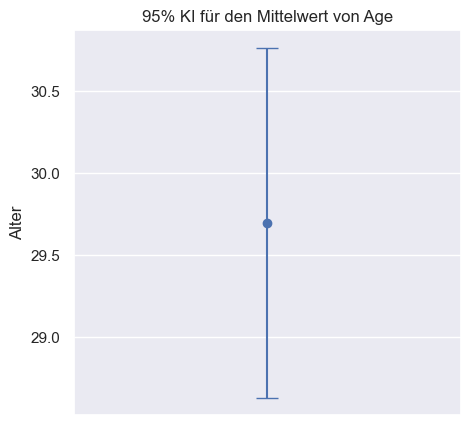

In [88]:
plt.figure(figsize=(5, 5))

plt.errorbar(
    x=[0],
    y=[xbar],
    yerr=[[xbar - ci_lower_t], [ci_upper_t - xbar]],
    fmt='o',
    capsize=8
)

plt.title("95% KI für den Mittelwert von Age")
plt.ylabel("Alter")
plt.xticks([])
plt.show()


### KI für den Anteil

Auch Anteile kann man als Punkt + Fehlerbalken darstellen.

Schätzer:

$$
\hat{p} = \text{Survived.mean()}
$$

Konfidenzintervall:

$$
\hat{p} \pm 1.96 \cdot SE(\hat{p})
$$


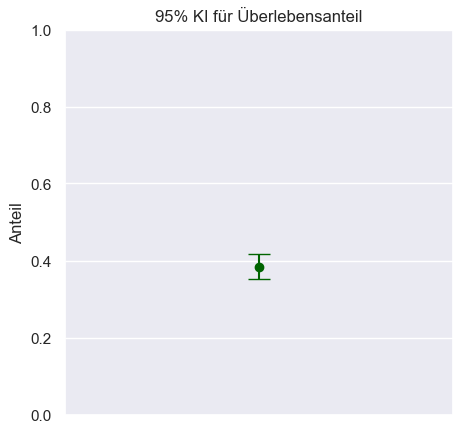

In [90]:
plt.figure(figsize=(5, 5))

plt.errorbar(
    x=[0],
    y=[p_hat],
    yerr=[[p_hat - ci_lower_p], [ci_upper_p - p_hat]],
    fmt='o',
    capsize=8,
    color="darkgreen"
)

plt.title("95% KI für Überlebensanteil")
plt.ylabel("Anteil")
plt.ylim(0, 1)
plt.xticks([])
plt.show()


### Optional: KI für die Standardabweichung

Wir haben im Abschnitt 5.5 das KI für die Varianz berechnet.
Durch Wurzelziehen erhalten wir ein KI für die Standardabweichung.

Auch dieses kann man darstellen:


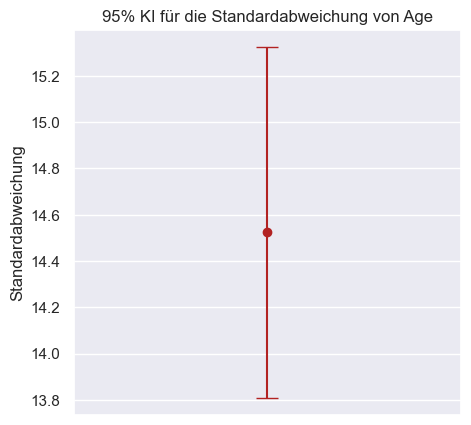

In [91]:
plt.figure(figsize=(5, 5))

sd_hat = np.sqrt(s2)

plt.errorbar(
    x=[0],
    y=[sd_hat],
    yerr=[[sd_hat - ci_sd_lower], [ci_sd_upper - sd_hat]],
    fmt='o',
    capsize=8,
    color="firebrick"
)

plt.title("95% KI für die Standardabweichung von Age")
plt.ylabel("Standardabweichung")
plt.xticks([])
plt.show()


### Vergleich: Punktschätzer + ihre KIs nebeneinander

Wir zeigen auf einen Blick:

- Mittelwert Age
- Überlebensanteil
- Standardabweichung Age

Das ist eine gute Visualisierung für Vorlesungen und Prüfungsverständnis.


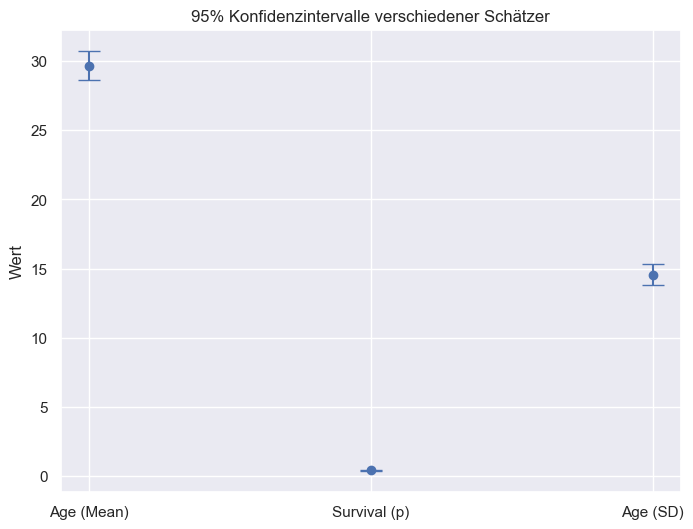

In [92]:
# Labels, Schätzer & KI-Unter-/Obergrenzen
labels = ["Age (Mean)", "Survival (p)", "Age (SD)"]
point_estimates = [xbar, p_hat, sd_hat]
ci_lowers = [ci_lower_t, ci_lower_p, ci_sd_lower]
ci_uppers = [ci_upper_t, ci_upper_p, ci_sd_upper]

# Fehler nach oben und unten
yerr_lower = [point_estimates[i] - ci_lowers[i] for i in range(3)]
yerr_upper = [ci_uppers[i] - point_estimates[i] for i in range(3)]
yerr = [yerr_lower, yerr_upper]

plt.figure(figsize=(8, 6))

plt.errorbar(
    x=labels,
    y=point_estimates,
    yerr=yerr,
    fmt='o',
    capsize=8,
    linestyle='none'
)

plt.title("95% Konfidenzintervalle verschiedener Schätzer")
plt.ylabel("Wert")
plt.show()


# Zusammenfassung Kapitel 5

- Punktschätzer liefern einzelne Schätzwerte für unbekannte Parameter (μ, p, σ²).
- Standardfehler misst die Streuung eines Schätzers (größeres n → kleinerer SE).
- Konfidenzintervalle: **Schätzer ± kritischer Wert · SE**.
- Wichtige KIs:
  - Mittelwert: Normal- oder t-Intervall  
  - Anteil: Normalapproximation  
  - Varianz: Chi²-Intervall
- KIs quantifizieren Unsicherheit eines Schätzers, nicht die Wahrscheinlichkeit für Parameterwerte.



# 6 Hypothesentests – Grundlagen

Hypothesentests beantworten Fragen der Form:

> “Ist der beobachtete Unterschied **zufällig** oder **systematisch**?”

Dazu formulieren wir zwei Hypothesen:


## **Nullhypothese \(H_0\)**  
Behauptet **keinen Effekt**, keinen Unterschied:

$$
H_0: \mu = \mu_0
$$

## **Alternativhypothese \(H_1\)**  
Behauptet **Effekt**, Unterschied:

$$
H_1: \mu \ne \mu_0 \quad \text{(zweiseitig)}
$$

oder  
$$
H_1: \mu > \mu_0
$$
$$
H_1: \mu < \mu_0
$$


## Teststatistik  
Eine Zahl, die misst, wie weit die Daten von \(H_0\) abweichen.

Beispiel: t-Statistik

$$
t = \frac{\bar{x} - \mu_0}{SE}
$$


## p-Wert  
Die Wahrscheinlichkeit, unter $H_0$ ein Ergebnis zu beobachten,  
das **genauso extrem oder extremer** ist als unser Wert.

---

## Entscheidungsregel  
- **p < 0.05** → wir lehnen $H_0$ ab  
- **p ≥ 0.05** → wir behalten $H_0$ bei  

(Dies bedeutet NICHT, dass $H_0$ „wahr“ ist — nur dass wir sie **nicht verwerfen können**.)


## 6.2 Fehler 1. und 2. Art

Bei Hypothesentests können zwei Fehler passieren:

### Fehler 1. Art (α-Fehler)
Wir verwerfen $H_0$, obwohl sie **stimmt**.

Wahrscheinlichkeit = Signifikanzniveau α (z.B. 0.05).

### Fehler 2. Art (β-Fehler)
Wir behalten $H_0$ bei, obwohl sie **falsch** ist.

Die Power ist:

$$
\text{Power} = 1 - \beta
$$

Sie misst, wie gut der Test echte Effekte entdeckt.


## 6.3 Der 4-Schritte-Ablauf eines Hypothesentests

1. **Hypothesen formulieren**
2. **Teststatistik berechnen** (oder Funktion aufrufen)
3. **p-Wert bestimmen**
4. **Entscheidung treffen** (bei α = 0.05)

Wir zeigen das jetzt mit Python.


## 6.4 Beispiel: t-Test für einen Mittelwert

## Beispiel: t-Test für einen Mittelwert
Frage: Ist das durchschnittliche Alter der Titanic-Passagiere ungleich 30?

### Hypothesen
$$
H_0 : \mu = 30
$$
$$
H_1 : \mu \ne 30
$$

Wir verwenden den **t-Test für eine Stichprobe**.


In [95]:
age = df["Age"].dropna()

# t-Test gegen mu0 = 30
result = stats.ttest_1samp(age, popmean=30, alternative="two-sided")
result


TtestResult(statistic=-0.5534583115970276, pvalue=0.5801231230388639, df=713)

### Interpretation

- Die Teststatistik t misst, wie viele Standardfehler die Daten von 30 entfernt liegen.
- Der p-Wert sagt, wie „extrem“ dieses Ergebnis unter \(H_0\) wäre.

Wenn **p < 0.05**, lehnen wir $H_0$ ab:

> Das mittlere Alter unterscheidet sich signifikant von 30 Jahren.


## 6.5 Beispiel: Test für einen Anteil (z-Test)

## Beispiel: z-Test für einen Anteil

Wir testen:

$$
H_0 : p = 0.4
$$
$$
H_1 : p \ne 0.4
$$

Wir benutzen die 0/1-Variable `Survived`.


In [97]:
from statsmodels.stats.proportion import proportions_ztest

count = df["Survived"].sum()
n = df["Survived"].shape[0]

stat, p_value = proportions_ztest(count, nobs=n, value=0.4)
stat, p_value


(-0.9919781789467331, 0.32120817012257874)

Wenn p < 0.05 → wir lehnen $H_0$ ab.

> Die Überlebensrate unterscheidet sich signifikant von 40%.


## 6.6 Beispiel: F-Test / Chi²-Test für Varianz (optional)

## Beispiel: Test auf Varianz

Wir testen:

$$
H_0 : \sigma^2 = 100
$$

Die Teststatistik ist:

$$
\chi^2 = \frac{(n-1)s^2}{100}
$$

Vergleich mit Chi²-Verteilung → p-Wert berechnen.


In [98]:
age = df["Age"].dropna()
n = age.shape[0]
s2 = age.var(ddof=1)
sigma2_0 = 100

chi2_stat = (n - 1) * s2 / sigma2_0

# p-Wert für zweiseitigen Test
p_lower = stats.chi2.cdf(chi2_stat, df=n-1)
p_upper = stats.chi2.sf(chi2_stat, df=n-1)
p_value = 2 * min(p_lower, p_upper)

chi2_stat, p_value


(1504.5663594411767, 2.0541000381682884e-58)

## 6.7 Beispiel: Vergleich zweier Mittelwerte (t-Test)

## Unabhängiger t-Test: Alter von Männern vs. Frauen

Hypothesen:

$$
H_0 : \mu_{\text{male}} = \mu_{\text{female}}
$$

$$
H_1 : \mu_{\text{male}} \ne \mu_{\text{female}}
$$


In [99]:
male_age = df[df["Sex"] == "male"]["Age"].dropna()
female_age = df[df["Sex"] == "female"]["Age"].dropna()

stats.ttest_ind(male_age, female_age, equal_var=False)  # Welch–Test


TtestResult(statistic=2.5258975171938896, pvalue=0.011814913211889735, df=560.0505568947057)

# Zusammenfassung Kapitel 6

- Hypothesentests prüfen, ob ein beobachteter Effekt zufällig sein kann.
- p-Wert: Wahrscheinlichkeit, unter \(H_0\) ein so extremes Ergebnis zu erhalten.
- Entscheidung: p < 0.05 → lehnen wir \(H_0\) ab.
- Wichtige Tests:
  - t-Test für Mittelwerte
  - z-Test für Anteile
  - Chi²-Tests für Varianz / Kontingenz
  - Welch-Test für Mittelwertvergleich bei ungleichen Varianzen

Hypothesentests folgen immer dem gleichen 4-Schritte-Plan.


# Kapitel 7 – Hypothesentests für eine Stichprobe

In diesem Kapitel testen wir, ob ein **Populationsparameter** einem vorgegebenen Wert entspricht.

Wir betrachten Tests für:

- einen Mittelwert  
- einen Anteilswert  
- eine Varianz  
- den Median (nichtparametrisch)  
- eine gesamte Verteilung (Chi²-Goodness-of-Fit, Normalitätstests)

Alle Tests folgen dem gleichen Schema:

1. **Hypothesen formulieren**
2. **Teststatistik berechnen**
3. **p-Wert bestimmen**
4. **Entscheidung bei $\alpha = 0.05$**

Mathematische Basis:

- Punktschätzer für Mittelwert:
  $$
  \bar{x} = \frac{1}{n}\sum_{i=1}^n X_i
  $$

- Standardfehler:
  $$
  SE(\bar{x}) = \frac{s}{\sqrt{n}}
  $$

- Teststatistik (t-Test):
  $$
  t = \frac{\bar{x} - \mu_0}{SE(\bar{x})}
  $$

# 7.1 Test für einen Mittelwert

Beispiel-Frage:  
„Ist die durchschnittliche Alter der Titanic-Passagiere gleich 30 Jahren?“

## Hypothesen

$$
H_0 : \mu = 30
$$

$$
H_1 : \mu \ne 30
$$

Wir verwenden den **t-Test für eine Stichprobe**.


In [101]:
age = df["Age"].dropna()

result = stats.ttest_1samp(age, popmean=30, alternative="two-sided")
result


TtestResult(statistic=-0.5534583115970276, pvalue=0.5801231230388639, df=713)

Interpretation:

- **p < 0.05 → Ablehnung von $H_0$**
- **p ≥ 0.05 → keine ausreichende Evidenz gegen $H_0$**

Der p-Wert sagt:  
Wie extrem ist unser Ergebnis **unter $H_0$**?


# 7.2 Test für einen Anteilswert

Beispiel-Frage:  
„Liegt die Überlebensrate bei 40%?“

Die Überlebensvariable ist 0/1 → Anteil ist:

$$
\hat{p} = \text{mean(Survived)}
$$

## Hypothesen

$$
H_0 : p = 0.4
$$

$$
H_1 : p \ne 0.4
$$

Wir verwenden den **z-Test für Anteile**.


In [102]:
from statsmodels.stats.proportion import proportions_ztest

count = df["Survived"].sum()
n = df["Survived"].shape[0]

stat, pval = proportions_ztest(count, nobs=n, value=0.4)
stat, pval


(-0.9919781789467331, 0.32120817012257874)

# 7.3 Test für eine Varianz

Beispiel-Frage:  
„Hat die Altersverteilung eine Varianz von 100?“

## Hypothesen

$$
H_0 : \sigma^2 = 100
$$

$$
H_1 : \sigma^2 \ne 100
$$

Teststatistik:

$$
\chi^2 = \frac{(n - 1)s^2}{\sigma_0^2}
$$

Vergleich mit der Chi²-Verteilung.


In [104]:
age = df["Age"].dropna()
n = len(age)
s2 = age.var(ddof=1)
sigma2_0 = 100

chi2_stat = (n - 1) * s2 / sigma2_0

p_lower = stats.chi2.cdf(chi2_stat, df=n-1)
p_upper = stats.chi2.sf(chi2_stat, df=n-1)
p_value = 2 * min(p_lower, p_upper)

chi2_stat, p_value


(1504.5663594411767, 2.0541000381682884e-58)

# 7.4 Test für den Median (Wilcoxon)

Wenn die Daten nicht normalverteilt sind oder starke Ausreißer enthalten,
testen wir den Median.

Beispiel-Frage:  
„Ist der Median des Alters = 30?“

## Hypothesen

$$
H_0 : \text{Median} = 30
$$

$$
H_1 : \text{Median} \ne 30
$$

Wir verwenden den **Wilcoxon Signed Rank Test**.


In [105]:
age_diff = age - 30
stats.wilcoxon(age_diff, alternative="two-sided")


WilcoxonResult(statistic=110449.5, pvalue=0.10779322780578604)

# 7.5 Chi²-Goodness-of-Fit-Test

Beispiel:  
„Ist die Klassenverteilung (Pclass = 1, 2, 3) gleichverteilt?“

## Hypothesen

$$
H_0 : \text{Beobachtete Verteilung} = \text{Erwartete Verteilung}
$$

$$
H_1 : \text{nicht gleich verteilt}
$$


In [106]:
obs = df["Pclass"].value_counts().sort_index()     # 1,2,3
exp = np.array([len(df)/3] * 3)                    # Gleichverteilung

stats.chisquare(f_obs=obs, f_exp=exp)


Power_divergenceResult(statistic=191.8047138047138, pvalue=2.2394202231028854e-42)

# 7.6 Tests für Normalverteilung

Wir prüfen:

- Shapiro-Wilk-Test (gut für kleinere n)
- Kolmogorov–Smirnov-Test (allgemein)

## Hypothesen

$$
H_0 : \text{Daten sind normalverteilt}
$$

$$
H_1 : \text{nicht normalverteilt}
$$


In [107]:
stats.shapiro(age.sample(500, random_state=0))


ShapiroResult(statistic=0.9796472718945214, pvalue=1.8787837568659487e-06)

In [108]:
stats.kstest((age - age.mean()) / age.std(), 'norm')


KstestResult(statistic=0.06456656793494475, pvalue=0.004958146899084225, statistic_location=0.02071265674426938, statistic_sign=1)

# Zusammenfassung Kapitel 7

- Tests für eine Stichprobe prüfen, ob ein Parameter einem Referenzwert entspricht.
- Wichtige Tests:
  - **t-Test**: Mittelwert
  - **z-Test**: Anteil
  - **Chi²-Test**: Varianz, Goodness-of-Fit
  - **Wilcoxon**: Median (nichtparametrisch)
  - **Shapiro / KS**: Normalität
- Entscheidung:
  - **p < 0.05 → $H_0$ verwerfen**
  - **p ≥ 0.05 → $H_0$ behalten**
- Jeder Test folgt dem gleichen Schema:
  1. Hypothesen  
  2. Teststatistik  
  3. p-Wert  
  4. Entscheidung  


# Kapitel 8 – Hypothesentests für zwei Stichproben

In diesem Kapitel vergleichen wir **zwei Gruppen**:

- zwei Mittelwerte  
- zwei Anteile  
- zwei Varianzen  
- zwei Mediane (nichtparametrisch)

Typische Beispiele:
- Männer vs. Frauen (Age, Fare, Survival)
- 1. Klasse vs. 3. Klasse
- Überlebende vs. Nichtüberlebende

---

## Grundidee

Wir testen, ob zwei Populationen gleiche Parameter haben.

Beispiel für Mittelwerte:

$$
H_0 : \mu_1 = \mu_2
$$

$$
H_1 : \mu_1 \ne \mu_2
$$

Die Struktur ist immer:

1. Hypothesen  
2. Teststatistik  
3. p-Wert  
4. Entscheidung  

---

Wir beginnen mit Mittelwerten.


# 8.1 t-Test für zwei unabhängige Stichproben

Beispiel-Frage:  
„Unterscheidet sich das durchschnittliche Alter von Männern und Frauen?“

## Hypothesen

$$
H_0 : \mu_{\text{male}} = \mu_{\text{female}}
$$

$$
H_1 : \mu_{\text{male}} \ne \mu_{\text{female}}
$$

Wir verwenden den Welch-Test (`equal_var=False`),  
weil Varianzen oft ungleich sind.


In [109]:
male_age = df[df["Sex"] == "male"]["Age"].dropna()
female_age = df[df["Sex"] == "female"]["Age"].dropna()

stats.ttest_ind(male_age, female_age, equal_var=False)


TtestResult(statistic=2.5258975171938896, pvalue=0.011814913211889735, df=560.0505568947057)

Interpretation:

- **p < 0.05 → signifikante Unterschiede**
- Welch-Test ist Standard, außer Varianzen sind sicher gleich.


# 8.2 t-Test für gepaarte Stichproben

Dieser Test wird benutzt, wenn beide Werte **zum selben Individuum** gehören.

Beispiele:
- Vorher–Nachher-Messungen
- Zwillinge
- A/B-Tests mit gleichen Teilnehmern

## Hypothesen

$$
H_0 : \mu_{\text{diff}} = 0
$$

$$
H_1 : \mu_{\text{diff}} \ne 0
$$

Auf dem Titanic-Datensatz nicht direkt sinnvoll, aber hier ist die Syntax.


# 8.3 Vergleich zweier Varianzen

Wir testen, ob die Varianzen zweier Gruppen gleich sind.

## Hypothesen

$$
H_0 : \sigma_1^2 = \sigma_2^2
$$

$$
H_1 : \sigma_1^2 \ne \sigma_2^2
$$

Wir verwenden:
- **Levene-Test** (robust gegen Nicht-Normalität)
- **Bartlett-Test** (sensibel, sollte nur bei Normalverteilung benutzt werden)


In [110]:
surv_f = df[df["Sex"] == "female"]["Survived"]
surv_m = df[df["Sex"] == "male"]["Survived"]

count = np.array([surv_f.sum(), surv_m.sum()])
nobs  = np.array([surv_f.size, surv_m.size])

proportions_ztest(count, nobs)


(16.218833930670097, 3.7117477701134797e-59)

# 8.5 Mann–Whitney U Test (Wilcoxon-Rangsumme)

Nichtparametrischer Test → verwendet bei:

- nicht-normalverteilten Daten
- ordinalen Skalen
- Ausreißern

Beispiel:  
Vergleich der Altersverteilung von Männern und Frauen.

## Hypothesen

$$
H_0 : \text{Verteilungen sind gleich}
$$

$$
H_1 : \text{Unterschied}
$$


In [111]:
stats.mannwhitneyu(male_age, female_age, alternative="two-sided")


MannwhitneyuResult(statistic=65020.5, pvalue=0.026087746884279634)

# 8.6 Chi²-Test für Unabhängigkeit

Beispiel-Frage:  
„Gibt es einen Zusammenhang zwischen Geschlecht und Überleben?“

Wir testen:

$$
H_0 : \text{Geschlecht und Überleben sind unabhängig}
$$

$$
H_1 : \text{Abhängigkeit}
$$

Wir verwenden eine Kreuztabelle und `chi2_contingency`.


In [112]:
table = pd.crosstab(df["Sex"], df["Survived"])
stats.chi2_contingency(table)


Chi2ContingencyResult(statistic=260.71702016732104, pvalue=1.1973570627755645e-58, dof=1, expected_freq=array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]]))

# Zusammenfassung Kapitel 8

- Zwei-Mittelwert-Tests:
  - t-Test / Welch-Test (unabhängig)
  - t-Test gepaart
- Zwei-Anteil-Tests:
  - z-Test für zwei Proportionen
- Varianzvergleiche:
  - Levene (robust)
  - Bartlett (sensibel)
- Nichtparametrisch:
  - Mann–Whitney U (Verteilungsvergleich)
- Kontingenz:
  - Chi²-Test für Unabhängigkeit

Alle Tests folgen:
1. Hypothesen  
2. Teststatistik  
3. p-Wert  
4. Entscheidung bei $\alpha=0.05$
